Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

Load Dataset

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Data Understanding

In [3]:
df.shape

(7043, 21)

In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Data Cleaning

In [8]:
# TotalCharges column (string → numeric)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [9]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

/tmp/ipython-input-2867/1479199042.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


In [12]:
# Remove useless column
df.drop("customerID", axis=1, inplace=True)

Exploratory Data Analysis (EDA)

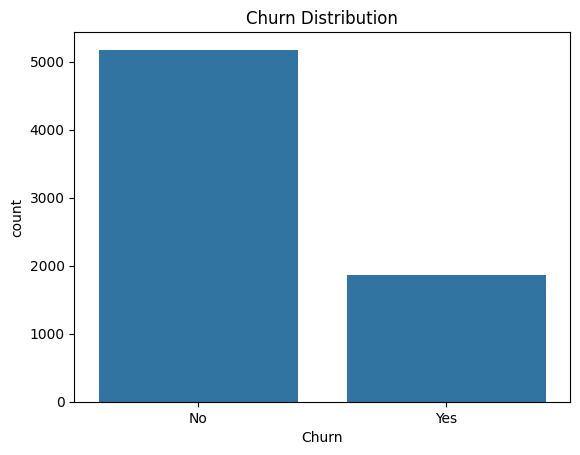

In [13]:
# Target distribution
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

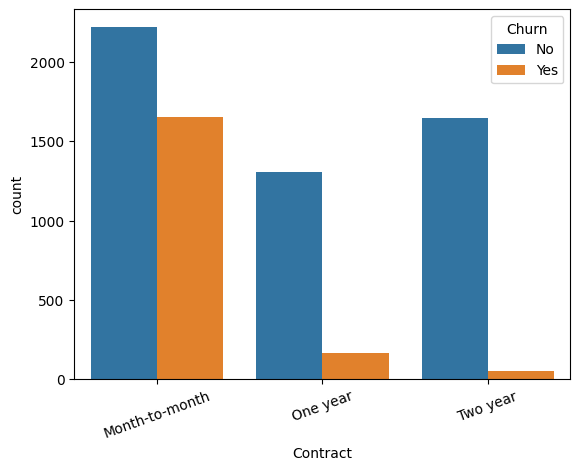

In [14]:
# Contract vs churn
sns.countplot(x="Contract", hue="Churn", data=df)
plt.xticks(rotation=20)
plt.show()

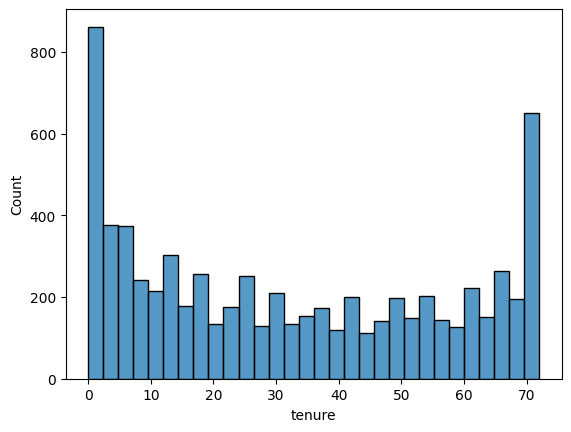

In [15]:
# Tenure distribution
sns.histplot(df["tenure"], bins=30)
plt.show()

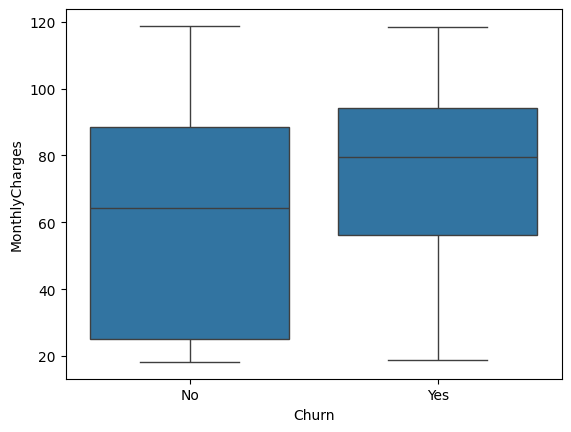

In [16]:
# Monthly charges vs churn
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

In [17]:
selected_columns = [
    'TotalCharges',
    'MonthlyCharges',
    'tenure',
    'Contract',
    'PaymentMethod',
    'OnlineSecurity',
    'TechSupport'
]

df_selected = df[selected_columns]
print(df_selected)

      TotalCharges  MonthlyCharges  tenure        Contract  \
0            29.85           29.85       1  Month-to-month   
1          1889.50           56.95      34        One year   
2           108.15           53.85       2  Month-to-month   
3          1840.75           42.30      45        One year   
4           151.65           70.70       2  Month-to-month   
...            ...             ...     ...             ...   
7038       1990.50           84.80      24        One year   
7039       7362.90          103.20      72        One year   
7040        346.45           29.60      11  Month-to-month   
7041        306.60           74.40       4  Month-to-month   
7042       6844.50          105.65      66        Two year   

                  PaymentMethod OnlineSecurity TechSupport  
0              Electronic check             No          No  
1                  Mailed check            Yes          No  
2                  Mailed check            Yes          No  
3     Bank 

In [18]:
print(df_selected['Contract'].unique())
print(df_selected['PaymentMethod'].unique())
print(df_selected['OnlineSecurity'].unique())
print(df_selected['TechSupport'].unique())

['Month-to-month' 'One year' 'Two year']
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']


Encode Categorical Variables

In [19]:
encoders = {}

for column in df.columns:
    if df[column].dtype == "object":
        le = LabelEncoder()
        df[column] = le.fit_transform(df[column])
        encoders[column] = le

In [20]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


Feature Selection using RF

In [21]:
# Split features and target
X_full = df.drop("Churn", axis=1)
y = df["Churn"]

# Train temporary RF to get imp. features
temp_rf = RandomForestClassifier(random_state=42)
temp_rf.fit(X_full, y)

# Get importance scores
importance = pd.Series(
    temp_rf.feature_importances_,
    index=X_full.columns
).sort_values(ascending=False)

# Show feature importance
print("Feature Importance:\n")
print(importance)

# Select top important features
top_features = importance.head(7).index.tolist()
print("\nSelected Features:", top_features)

Feature Importance:

TotalCharges        0.188243
MonthlyCharges      0.181344
tenure              0.158132
Contract            0.079598
PaymentMethod       0.051067
OnlineSecurity      0.045266
TechSupport         0.043398
gender              0.027768
InternetService     0.027341
OnlineBackup        0.027158
PaperlessBilling    0.024958
MultipleLines       0.022688
Partner             0.021903
DeviceProtection    0.021339
SeniorCitizen       0.020991
Dependents          0.019642
StreamingTV         0.017403
StreamingMovies     0.017028
PhoneService        0.004734
dtype: float64

Selected Features: ['TotalCharges', 'MonthlyCharges', 'tenure', 'Contract', 'PaymentMethod', 'OnlineSecurity', 'TechSupport']


In [22]:
# Split Features & Target - Create new dataset with selected features
X = X_full[top_features]
y = df["Churn"]

Feature Scaling

In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [24]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

Train Multiple Models

In [25]:
# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [26]:
# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

In [27]:
# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [28]:
# SVM
svm = SVC(probability=True)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

In [29]:
# KNN
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

Model Evaluation

In [30]:
def evaluate_model(name, y_true, y_pred):
    print("MODEL:", name)
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print(classification_report(y_true, y_pred))
    print("-"*50)

In [31]:
evaluate_model("Logistic Regression", y_test, lr_pred)
evaluate_model("Decision Tree", y_test, dt_pred)
evaluate_model("Random Forest", y_test, rf_pred)
evaluate_model("SVM", y_test, svm_pred)
evaluate_model("KNN", y_test, knn_pred)

MODEL: Logistic Regression
Accuracy: 0.8005677785663591
[[920 116]
 [165 208]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1036
           1       0.64      0.56      0.60       373

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409

--------------------------------------------------
MODEL: Decision Tree
Accuracy: 0.7374024130589071
[[847 189]
 [181 192]]
              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1036
           1       0.50      0.51      0.51       373

    accuracy                           0.74      1409
   macro avg       0.66      0.67      0.67      1409
weighted avg       0.74      0.74      0.74      1409

--------------------------------------------------
MODEL: Random Forest
Accuracy: 0.7877927608232789
[[924 112]
 [187 186]]
              preci

ROC AUC Score Comparison

In [32]:
models = {
    "LR": lr,
    "DT": dt,
    "RF": rf,
    "SVM": svm,
    "KNN": knn
}

for name, model in models.items():
    prob = model.predict_proba(X_test)[:,1]
    score = roc_auc_score(y_test, prob)
    print(name, "ROC AUC:", score)

LR ROC AUC: 0.85596023062511
DT ROC AUC: 0.670641102611612
RF ROC AUC: 0.8239076878487067
SVM ROC AUC: 0.7977941557030029
KNN ROC AUC: 0.7945244651008727


Save Model

In [33]:
import pickle

pickle.dump(lr, open("churn_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(top_features, open("features.pkl", "wb"))
pickle.dump(encoders, open("encoders.pkl", "wb"))